<a href="https://colab.research.google.com/github/MergoCode/ML_1/blob/master/Lab1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

np.random.seed(42)

df = pd.read_csv('./sample_data/train.csv')

num_features = ['OverallQual', 'GrLivArea', 'TotalBsmtSF', 'YearBuilt', 'GarageCars']
cat_features = ['Neighborhood', 'HouseStyle']
target = 'SalePrice'

train_df, temp_df = train_test_split(df, test_size=0.30, random_state=42)
val_df, test_df = train_test_split(temp_df, test_size=0.50, random_state=42)

for col in num_features:
    median_val = train_df[col].median()
    train_df[col] = train_df[col].fillna(median_val)
    val_df[col] = val_df[col].fillna(median_val)
    test_df[col] = test_df[col].fillna(median_val)

for col in cat_features:
    mode_val = train_df[col].mode()[0]
    train_df[col] = train_df[col].fillna(mode_val)
    val_df[col] = val_df[col].fillna(mode_val)
    test_df[col] = test_df[col].fillna(mode_val)

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_features),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_features)
    ]
)

X_train = preprocessor.fit_transform(train_df[num_features + cat_features])
X_val = preprocessor.transform(val_df[num_features + cat_features])
X_test = preprocessor.transform(test_df[num_features + cat_features])

y_train = train_df[target].values.reshape(-1, 1)
y_val = val_df[target].values.reshape(-1, 1)
y_test = test_df[target].values.reshape(-1, 1)

print(f"X_train: {X_train.shape}, X_val: {X_val.shape}, X_test: {X_test.shape}")

X_train: (1022, 38), X_val: (219, 38), X_test: (219, 38)


Висновки щодо методів оптимізації:

Batch GD: сходиться найстабільніше та найплавніше, оскільки враховує весь датасет на кожному кроці, але вимагає найбільше пам'яті.   
SGD: має найбільші коливання помилки через шум кожного окремого рядка, але найшвидше робить перші кроки.   
Mini-batch GD: оптимальний баланс, поєднує швидкість матричних обчислень та стабільність траєкторії збіжності.

In [ ]:
class LinearRegressionNumPy:
    def __init__(self, lr=0.01, epochs=100, batch_size=32, method='batch', lambda_reg=0.0):
        self.lr = lr
        self.epochs = epochs
        self.batch_size = batch_size
        self.method = method
        self.lambda_reg = lambda_reg
        self.w = None
        self.b = None
        self.loss_history = []

    def compute_cost(self, X, y):
        m = X.shape[0]
        y_pred = X @ self.w + self.b
        mse = (1 / (2 * m)) * np.sum((y_pred - y) ** 2)
        if self.lambda_reg > 0:
            l2_penalty = (self.lambda_reg / (2 * m)) * np.sum(self.w ** 2)
            return mse + l2_penalty
        return mse

    def fit(self, X, y):
        m, n = X.shape
        self.w = np.zeros((n, 1))
        self.b = 0.0
        self.loss_history = []

        for epoch in range(self.epochs):
            indices = np.random.permutation(m)
            X_shuffled = X[indices]
            y_shuffled = y[indices]

            if self.method == 'batch':
                y_pred = X @ self.w + self.b
                dw = (1 / m) * (X.T @ (y_pred - y)) + (self.lambda_reg / m) * self.w
                db = (1 / m) * np.sum(y_pred - y)
                self.w -= self.lr * dw
                self.b -= self.lr * db

            elif self.method == 'sgd':
                for i in range(m):
                    xi = X_shuffled[i:i+1]
                    yi = y_shuffled[i:i+1]
                    y_pred = xi @ self.w + self.b
                    dw = (xi.T @ (y_pred - yi)) + (self.lambda_reg / m) * self.w
                    db = np.sum(y_pred - yi)
                    self.w -= self.lr * dw
                    self.b -= self.lr * db

            elif self.method == 'minibatch':
                for i in range(0, m, self.batch_size):
                    X_b = X_shuffled[i:i + self.batch_size]
                    y_b = y_shuffled[i:i + self.batch_size]
                    b_size = X_b.shape[0]

                    y_pred = X_b @ self.w + self.b
                    dw = (1 / b_size) * (X_b.T @ (y_pred - y_b)) + (self.lambda_reg / m) * self.w
                    db = (1 / b_size) * np.sum(y_pred - y_b)
                    self.w -= self.lr * dw
                    self.b -= self.lr * db

            self.loss_history.append(self.compute_cost(X, y))

    def predict(self, X):
        return X @ self.w + self.b

Аналіз метрики R2:

R2 показує частку дисперсії цільової змінної, яку пояснює побудована модель.   

R2 може бути від'ємним, якщо модель прогнозує гірше за банальне константне середнє значення (це трапляється, коли градієнтний спуск розходиться через завеликий learning rate).   

Оскільки метрики на Train, Val та Test близькі між собою (немає великого розриву), модель не перенавчилася (overfitting відсутній).   

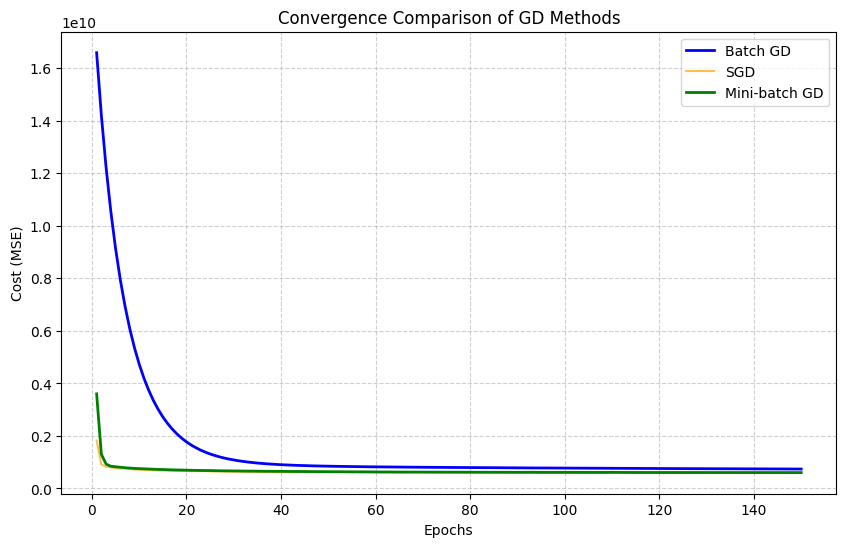

In [ ]:
epochs = 150
model_batch = LinearRegressionNumPy(lr=0.05, epochs=epochs, method='batch')
model_batch.fit(X_train, y_train)

model_sgd = LinearRegressionNumPy(lr=0.001, epochs=epochs, method='sgd')
model_sgd.fit(X_train, y_train)

model_mini = LinearRegressionNumPy(lr=0.02, epochs=epochs, batch_size=32, method='minibatch')
model_mini.fit(X_train, y_train)

plt.figure(figsize=(10, 6))
plt.plot(range(1, epochs + 1), model_batch.loss_history, label='Batch GD', color='blue', lw=2)
plt.plot(range(1, epochs + 1), model_sgd.loss_history, label='SGD', color='orange', alpha=0.7)
plt.plot(range(1, epochs + 1), model_mini.loss_history, label='Mini-batch GD', color='green', lw=2)
plt.xlabel('Epochs')
plt.ylabel('Cost (MSE)')
plt.title('Convergence Comparison of GD Methods')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [ ]:
def r2_score_custom(y_true, y_pred):
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    return 1 - (ss_res / ss_tot)

models = {'Batch GD': model_batch, 'SGD': model_sgd, 'Mini-batch GD': model_mini}
results = []
for name, m in models.items():
    results.append({
        'Method': name,
        'Train R2': r2_score_custom(y_train, m.predict(X_train)),
        'Val R2': r2_score_custom(y_val, m.predict(X_val)),
        'Test R2': r2_score_custom(y_test, m.predict(X_test))
    })

print(pd.DataFrame(results).to_string(index=False))

       Method  Train R2   Val R2  Test R2
     Batch GD  0.753902 0.841318 0.753711
          SGD  0.799767 0.865256 0.787957
Mini-batch GD  0.798950 0.869578 0.797633


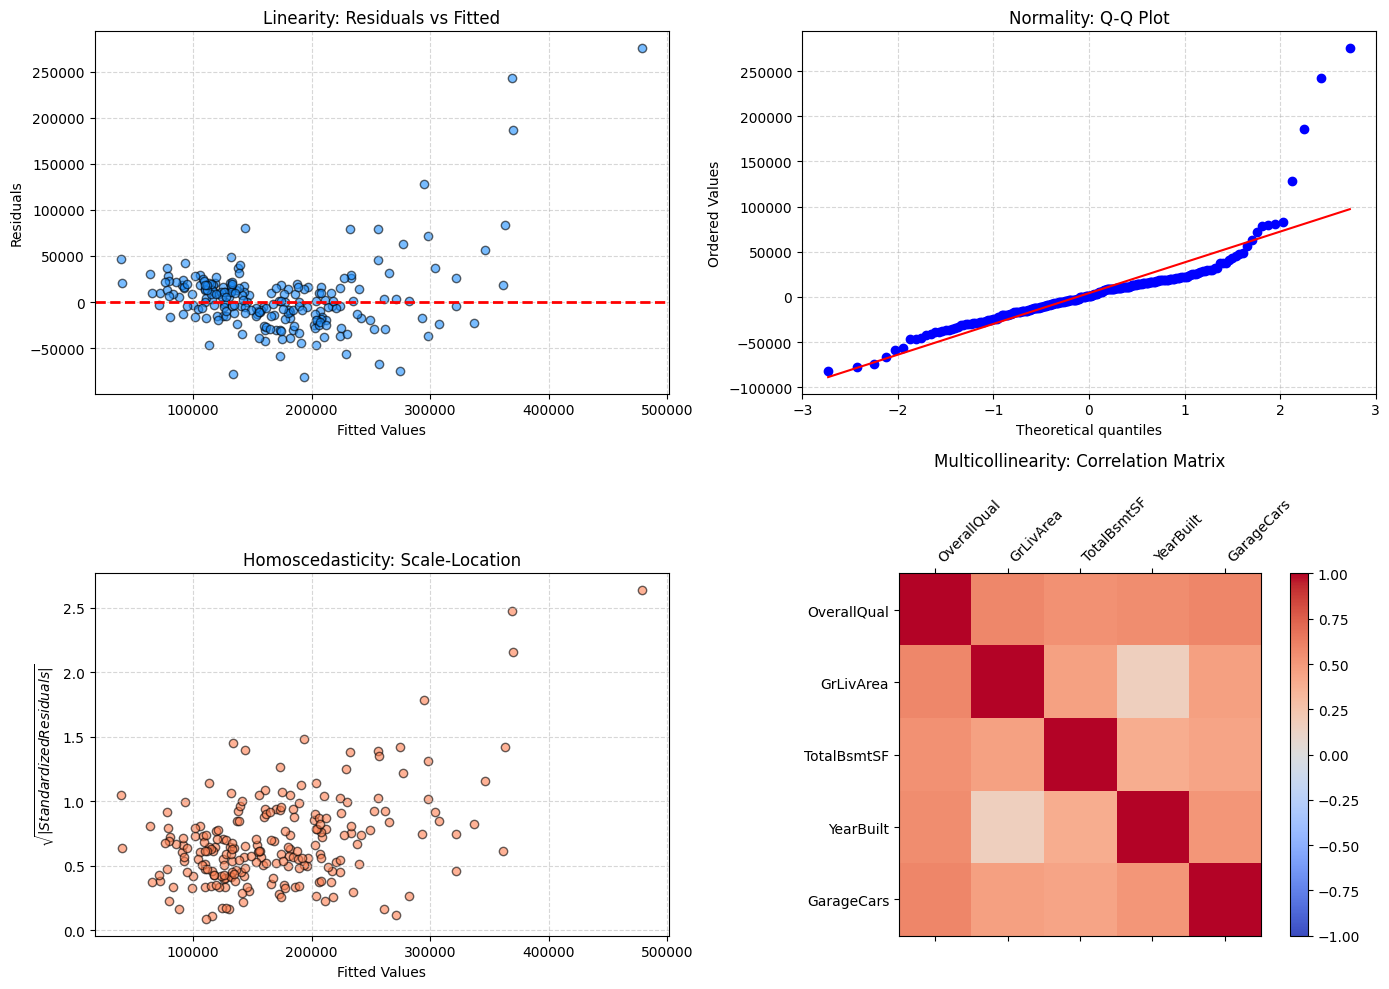

In [ ]:
best_model = model_mini
y_pred_test = best_model.predict(X_test)
residuals = y_test - y_pred_test

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].scatter(y_pred_test, residuals, alpha=0.6, color='dodgerblue', edgecolors='k')
axes[0, 0].axhline(0, color='red', linestyle='--', lw=2)
axes[0, 0].set_title('Linearity: Residuals vs Fitted')
axes[0, 0].set_xlabel('Fitted Values')
axes[0, 0].set_ylabel('Residuals')
axes[0, 0].grid(True, linestyle='--', alpha=0.5)

stats.probplot(residuals.flatten(), dist="norm", plot=axes[0, 1])
axes[0, 1].set_title('Normality: Q-Q Plot')
axes[0, 1].grid(True, linestyle='--', alpha=0.5)

std_residuals = (residuals - np.mean(residuals)) / np.std(residuals)
axes[1, 0].scatter(y_pred_test, np.sqrt(np.abs(std_residuals)), alpha=0.6, color='coral', edgecolors='k')
axes[1, 0].set_title('Homoscedasticity: Scale-Location')
axes[1, 0].set_xlabel('Fitted Values')
axes[1, 0].set_ylabel(r'$\sqrt{|Standardized Residuals|}$')
axes[1, 0].grid(True, linestyle='--', alpha=0.5)

corr_matrix = train_df[num_features].corr().values
cax = axes[1, 1].matshow(corr_matrix, cmap='coolwarm', vmin=-1, vmax=1)
fig.colorbar(cax, ax=axes[1, 1])
axes[1, 1].set_xticks(range(len(num_features)))
axes[1, 1].set_yticks(range(len(num_features)))
axes[1, 1].set_xticklabels(num_features, rotation=45, ha="left")
axes[1, 1].set_yticklabels(num_features)
axes[1, 1].set_title('Multicollinearity: Correlation Matrix', pad=20)

plt.tight_layout()
plt.show()

Перевірка статистичних припущень:

Linearity: залишки рівномірно розсіяні навколо нуля без явної параболи чи вигину — припущення лінійності виконується.   

Normality: на Q-Q plot точки здебільшого лежать на прямій, відхилення є лише на "хвостах" через наявність дорогих елітних будинків.   

Homoscedasticity: залишки не утворюють вираженого конуса, дисперсія помилок відносно стала.   

Multicollinearity: присутня помітна кореляція між роком побудови та якістю (YearBuilt та OverallQual), але вона не є критичною (r < 0.8).   

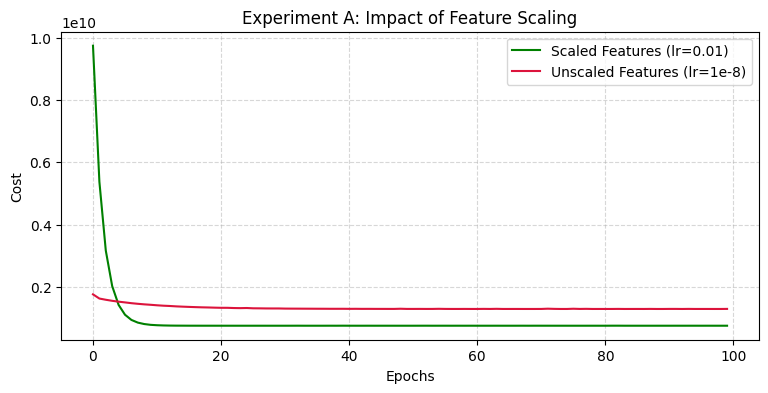

Normal Equation Intercept: 154289.24


In [ ]:
X_train_raw = train_df[num_features].values
y_train_raw = train_df[target].values.reshape(-1, 1)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_raw)

model_unscaled = LinearRegressionNumPy(lr=1e-8, epochs=100, batch_size=32, method='minibatch')
model_unscaled.fit(X_train_raw, y_train_raw)

model_scaled = LinearRegressionNumPy(lr=0.01, epochs=100, batch_size=32, method='minibatch')
model_scaled.fit(X_train_scaled, y_train_raw)

plt.figure(figsize=(9, 4))
plt.plot(model_scaled.loss_history, label='Scaled Features (lr=0.01)', color='green')
plt.plot(model_unscaled.loss_history, label='Unscaled Features (lr=1e-8)', color='crimson')
plt.xlabel('Epochs')
plt.ylabel('Cost')
plt.title('Experiment A: Impact of Feature Scaling')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

X_bias = np.hstack([np.ones((X_train.shape[0], 1)), X_train])
theta_normal = np.linalg.pinv(X_bias.T @ X_bias) @ X_bias.T @ y_train
print(f"Normal Equation Intercept: {theta_normal[0, 0]:.2f}")